# Visualization Exercise: Kaggle Data Science Survey 2020

Time to put your skills to work on a **real-world dataset**!

In this notebook you will build publication-ready and stakeholder-ready visualizations from the 2020 Kaggle Data Science Survey, a global snapshot of who data scientists are, what tools they use, and how much they earn.

You will use all three libraries from the intro notebook:

- **Matplotlib** for at least one plot

- **Seaborn** for at least one plot

- **Plotly** for at least one interactive plot

> **Before you start**: run notebook **3_Fetching_the_data.ipynb** first to create `data/kaggle_survey.csv`.

## Learning Objectives

1. Load and explore a real-world survey dataset

2. Prepare data for visualization (clean, aggregate, reshape)

3. Create **explanatory** visualizations that clearly answer specific stakeholder questions

4. Choose the right library and chart type for each question

5. Apply professional formatting (titles, labels, colour, annotations)

## Dataset Overview

The CSV contains responses to 18 survey questions. Here is a reference table:

| Column | Question |
|---|---|
| `age_range` | What is your age? |
| `gender` | What is your gender? |
| `county_residence` | In which country do you currently reside? |
| `highest_education` | Highest level of formal education |
| `latest_job_role` | Current job title |
| `years_of_programming` | Years writing code |
| `programming_language_recommended` | What language would you recommend first? |
| `computing_platforms` | Primary computing platform for data science |
| `years_of_experience` | Years using machine learning methods |
| `size_of_company` | Size of employer |
| `number_of_data_scientists` | Data scientists at your employer |
| `employer_incorporate_ml` | Does your employer use ML methods? |
| `yearly_earnings` | Current yearly compensation (USD) |
| `money_spend_on_cloud` | Spend on ML / cloud services in past 5 years |
| `most_used_data_products` | Primary big data / database product |
| `most_used_bi_tool` | Primary BI tool |
| `primary_tool_data_analysis` | Primary tool for data analysis |


## Setup and Import

In [1]:
# --- Import all required libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("Libraries ready!")

Libraries ready!


In [5]:
# --- Load the Kaggle survey dataset ---
# Run 3_Fetching_the_data.ipynb first if this file does not exist
df = pd.read_csv("data/kaggle_survey.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (20036, 19)


,id,age_range,gender,county_residence,highest_education,latest_job_role,years_of_programming,programming_language_recommended,computing_platforms,times_tpu_used,years_of_experience,size_of_company,number_of_data_scientists,employer_incorporate_ml,yearly_earnings,money_spend_on_cloud,most_used_data_products,most_used_bi_tool,primary_tool_data_analysis
0,7232,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,Python,"A cloud computing platform (AWS, Azure, GCP, h...",2-5 times,1-2 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Basic statistical software (Microsoft Excel, G..."
1,7233,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,Python,A personal computer or laptop,2-5 times,1-2 years,"10,000 or more employees",20+,"We have well established ML methods (i.e., mod...","100,000-124,999","$100,000 or more ($USD)",PostgresSQL,Microsoft Power BI,"Business intelligence software (Salesforce, Ta..."
2,7234,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,R,A personal computer or laptop,Never,I do not use machine learning methods,"1000-9,999 employees",0,No (we do not use ML methods),"15,000-19,999",$0 ($USD),NaN,NaN,"Basic statistical software (Microsoft Excel, G..."
3,7235,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,Python,"A cloud computing platform (AWS, Azure, GCP, h...",2-5 times,3-4 years,250-999 employees,5-9,"We have well established ML methods (i.e., mod...","125,000-149,999","$10,000-$99,999",MySQL,NaN,"Local development environments (RStudio, Jupyt..."
4,7236,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Getting to Know the Data

Before you visualize, **always explore**. Surprises at this stage save hours later.

Work through the cells below to understand the structure, column types, and distribution of values.

In [6]:
# --- Inspect data types and missing values ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20036 entries, 0 to 20035
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   id                                20036 non-null  int64
 1   age_range                         20036 non-null  str  
 2   gender                            20036 non-null  str  
 3   county_residence                  20036 non-null  str  
 4   highest_education                 19569 non-null  str  
 5   latest_job_role                   19277 non-null  str  
 6   years_of_programming              19120 non-null  str  
 7   programming_language_recommended  17740 non-null  str  
 8   computing_platforms               16737 non-null  str  
 9   times_tpu_used                    16780 non-null  str  
 10  years_of_experience               16374 non-null  str  
 11  size_of_company                   11403 non-null  str  
 12  number_of_data_scientists         11282 non

In [7]:
# --- Check unique values in key categorical columns ---
for col in ["latest_job_role", "gender", "highest_education"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10))


latest_job_role (13 unique values):
latest_job_role
Student                      5171
Data Scientist               2676
Software Engineer            1968
Other                        1737
Currently not employed       1652
Data Analyst                 1475
Research Scientist           1174
Machine Learning Engineer    1082
Business Analyst              798
Product/Project Manager       692
Name: count, dtype: int64

gender (5 unique values):
gender
Man                        15789
Woman                       3878
Prefer not to say            263
Prefer to self-describe       54
Nonbinary                     52
Name: count, dtype: int64

highest_education (7 unique values):
highest_education
Master’s degree                                                      7859
Bachelor’s degree                                                    6978
Doctoral degree                                                      2302
Some college/university study without earning a bachelor’s degree    1092
Prof

In [8]:
# --- Check for missing data ---
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

most_used_bi_tool                   18538
most_used_data_products             16523
money_spend_on_cloud                 9466
yearly_earnings                      9307
employer_incorporate_ml              8906
number_of_data_scientists            8754
size_of_company                      8633
primary_tool_data_analysis           6746
years_of_experience                  3662
computing_platforms                  3299
times_tpu_used                       3256
programming_language_recommended     2296
years_of_programming                  916
latest_job_role                       759
highest_education                     467
dtype: int64

---

## Checkpoint A: Understanding the Data

Answer these before writing any visualization code:

1. How many survey respondents are there in total?

2. How many unique job roles are in the dataset?

3. Which column has the most missing values?

4. What format is the `yearly_earnings` column in, is it ready to plot directly?

5. If you wanted to plot the number of respondents per country, which column would you use?


---

## Challenge 1: Salary Comparison by Job Role

**Stakeholder question**: *"We want a visual comparison of the yearly compensation of Data Scientists, Data Analysts, and Data Engineers."*

**Chart type suggestion**: Box plot or violin plot (shows distribution, not just average)

**Library suggestion**: Seaborn or Plotly (interactivity helps here)

### Data Preparation

The `yearly_earnings` column contains strings like `'$10,000-$14,999'`. The helper code below converts these to a single integer (the lower bound of the range). You must use `data_compensation` for your plot.

In [9]:
# --- Helper: convert salary strings to integers ---
# Pandas 3.0 note: use .copy() to avoid SettingWithCopyWarning under Copy-on-Write
compensation = df[["latest_job_role", "yearly_earnings"]].copy()
compensation = compensation.dropna()


def get_first_number(x):
    """Extract the lower bound from a salary range string."""
    x = x.split("-")[0]
    x = x.replace(",", "").replace(">", "").replace("$", "").strip()
    return int(x)


# Apply the function to create a clean numeric salary column
compensation["salary_usd"] = compensation["yearly_earnings"].apply(get_first_number)

# Filter to the three roles of interest
roles_of_interest = ["Data Scientist", "Data Analyst", "Data Engineer"]
data_compensation = compensation[
    compensation["latest_job_role"].isin(roles_of_interest)
]

print(f"Rows available: {len(data_compensation)}")
data_compensation.head()

Rows available: 4027


,latest_job_role,yearly_earnings,salary_usd
1,Data Engineer,"100,000-124,999",100000
3,Data Scientist,"125,000-149,999",125000
8,Data Scientist,"70,000-79,999",70000
13,Data Engineer,"90,000-99,999",90000
21,Data Scientist,$0-999,0


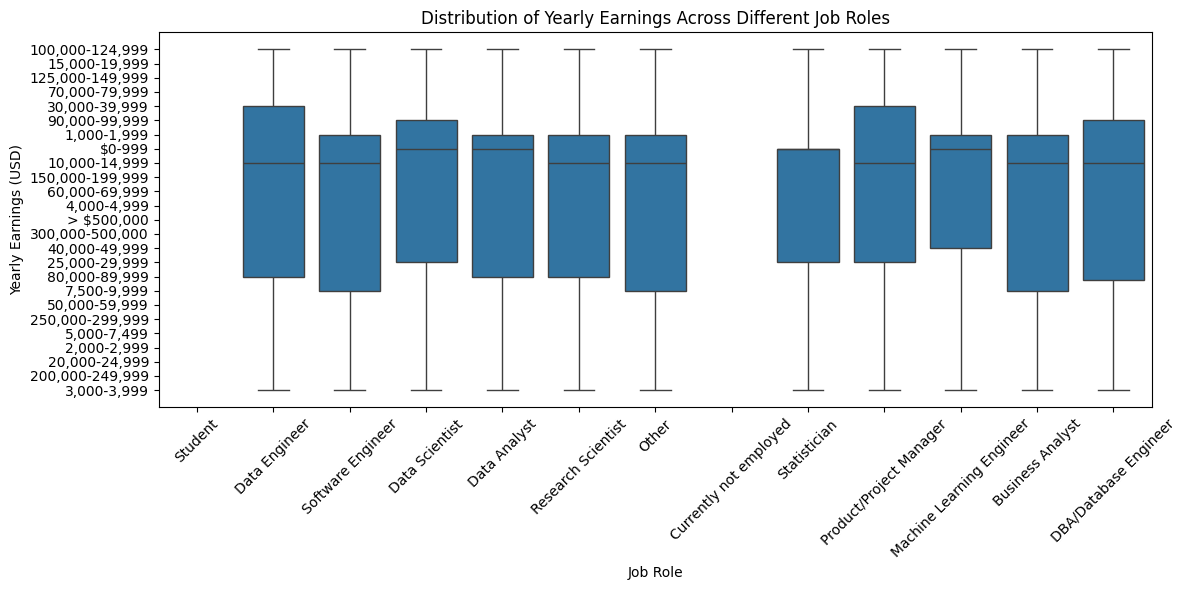

In [16]:
# Create a plot that clearly shows salary distributions for the three roles
# Requirements:
#   - Show the distribution (not just mean), use box, violin, or strip plot
#   - Label axes clearly with units
#   - Add a descriptive title
#   - Use at least one of: Seaborn or Plotly

# --- YOUR CODE HERE ---

import seaborn as sns
import matplotlib.pyplot as plt

# Plot salary distributions by job role
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="latest_job_role",
    y="yearly_earnings",
    
)

# Labels and title
plt.xlabel("Job Role")
plt.ylabel("Yearly Earnings (USD)")
plt.title("Distribution of Yearly Earnings Across Different Job Roles")

# Improve readability
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


---

## Checkpoint B: Before You Move On

Review your Challenge 1 plot:

1. Can a non-technical person understand what the chart shows without reading the code?

2. Are the axes labelled with the variable name AND unit (USD)?

3. Can you see the median AND the spread for each role?

4. Is the title a statement or finding, not just a description?
   - Weak: *'Salary by Job Role'*
   - Strong: *'Data Engineers Tend to Earn More Than Data Analysts'*


---

## Challenge 2: Gender Distribution by Country

**Stakeholder question**: *"Show the gender distribution in the top 10 countries by total survey participation. Also show the top 10 countries with the most female participants."*

**This is actually two related plots:**

- **Plot 2a**: Top 10 countries by total respondents, stacked or grouped bar, coloured by gender

- **Plot 2b**: Top 10 countries by female respondents, bar or horizontal bar chart

**Hints**:

- Use `df['county_residence'].value_counts()` to find the top countries

- Filter to only the top 10 before plotting

- For stacked bars in Seaborn, you may need to `pivot` the data first

- For Plotly, `barmode='stack'` or `barmode='group'` handles this automatically

In [17]:
# --- Starter code: find top 10 countries by total participants ---
top_10_countries = df["county_residence"].value_counts().head(10).index.tolist()
print("Top 10 countries:", top_10_countries)

# Filter df to only these countries
df_top10 = df[df["county_residence"].isin(top_10_countries)].copy()

Top 10 countries: ['India', 'United States of America', 'Other', 'Brazil', 'Japan', 'Russia', 'United Kingdom of Great Britain and Northern Ireland', 'Nigeria', 'China', 'Germany']


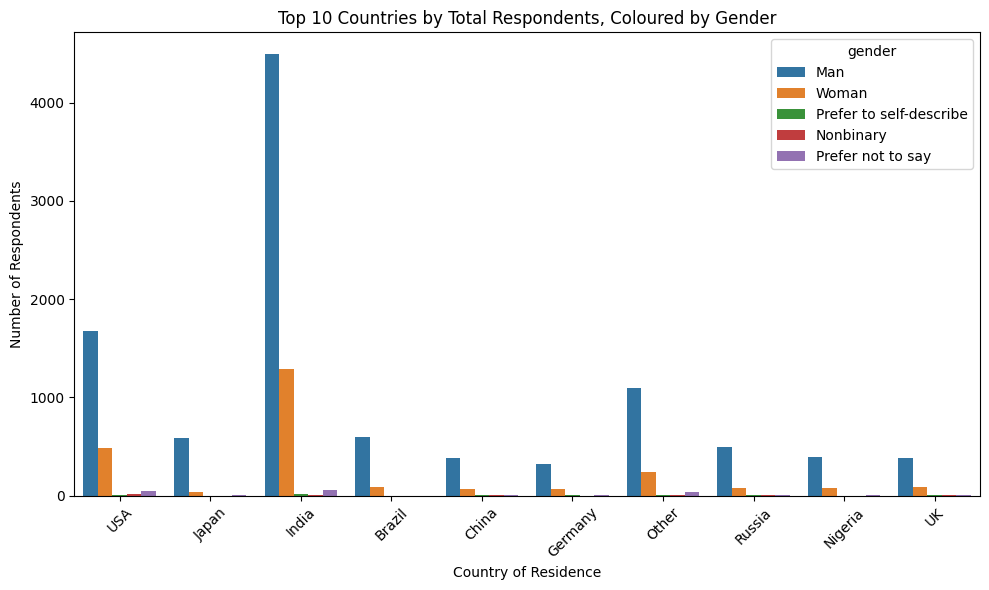

In [32]:
# --- YOUR CODE HERE: Plot 2a ---
# Top 10 countries by total respondents, coloured by gender

import seaborn as sns
import matplotlib.pyplot as plt

# Plot top 10 countries by respondents, coloured by gender

plt.figure(figsize=(10, 6))

country_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Other": "Other",
    "India": "India",
    "Brazil": "Brazil",
    "Japan": "Japan",
    "Russia": "Russia",
    "Nigeria": "Nigeria",
    "China": "China",
    "Germany": "Germany"
}
df_top10["country_short"] = df_top10["county_residence"].map(country_names)

sns.countplot(
    data=df_top10,
    x="country_short",
    hue="gender"
) 

# Labels and title
plt.xlabel("Country of Residence")
plt.ylabel("Number of Respondents")
plt.title("Top 10 Countries by Total Respondents, Coloured by Gender")

# Improve readability
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

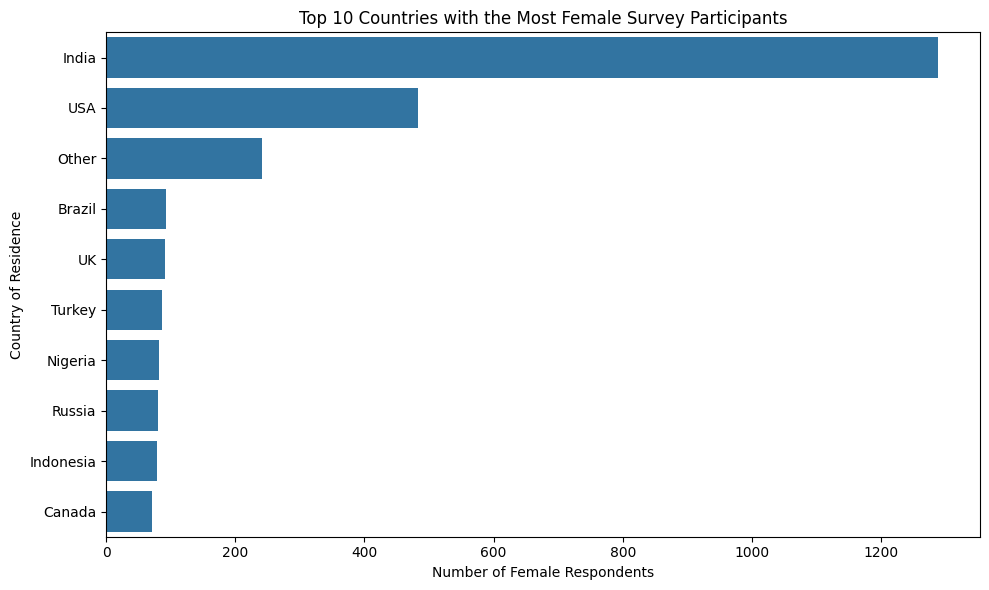

In [46]:
# --- YOUR CODE HERE: Plot 2b ---
# Top 10 countries with the most female survey participants
# Hint: filter df for gender == 'Woman', then count by country

female_counts = (
    df[df["gender"] == "Woman"]
    .groupby("county_residence")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="female_count")
)

country_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Other": "Other",
    "India": "India",
    "Brazil": "Brazil",
    "Japan": "Japan",
    "Russia": "Russia",
    "Nigeria": "Nigeria",
    "China": "China",
    "Germany": "Germany"
}
female_counts["country_short"] = female_counts["county_residence"].map(country_names).fillna(
    female_counts["county_residence"]
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=female_counts,
    x="female_count",
    y="country_short",
)

plt.xlabel("Number of Female Respondents")
plt.ylabel("Country of Residence")
plt.title("Top 10 Countries with the Most Female Survey Participants")
plt.tight_layout()
plt.show()



---

## Challenge 3: Recommended Programming Languages

**Stakeholder question**: *"Python is clearly recommended most. What is the second most recommended language? And does the answer change depending on whether the respondent is a Data Scientist, Data Analyst, or Data Engineer?"*

**Approach**:
1. First, find the overall ranking (all respondents, excluding Python)

2. Then, compare the rankings across the three job roles side by side

**Chart type suggestions**:
- A horizontal bar chart (or Plotly bar) for the overall ranking

- A grouped bar or faceted chart for the job-role comparison

**Hint**: `df[df['programming_language_recommended'] != 'Python']` filters out Python.

In [47]:
# --- Starter code: overall language recommendations (excluding Python) ---
no_python = df[df["programming_language_recommended"] != "Python"].copy()
lang_counts = no_python["programming_language_recommended"].value_counts().reset_index()
lang_counts.columns = ["language", "count"]
print(lang_counts.head(10))

     language  count
0           R   1259
1         SQL    849
2         C++    325
3           C    301
4      MATLAB    195
5        Java    167
6       Other    151
7       Julia    121
8  Javascript     88
9        Bash     26


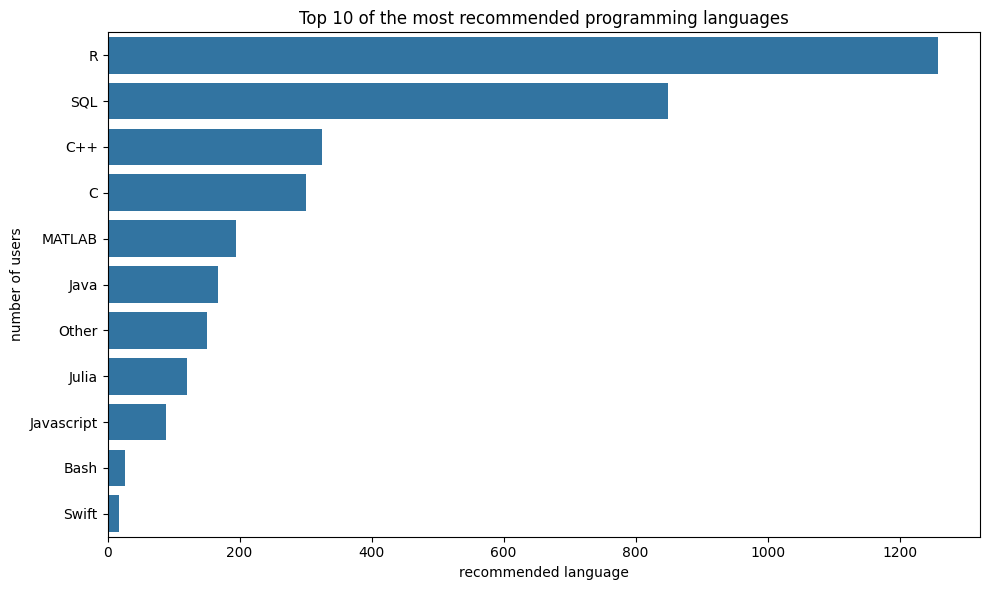

In [49]:
# --- YOUR CODE HERE: Plot 3a ---
# Overall recommended language (excluding Python)
# Suggestion: horizontal bar chart (easier to read language names on y-axis)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lang_counts,
    x="count",
    y="language",
)

plt.xlabel("recommended language")
plt.ylabel("number of users")
plt.title("Top 10 of the most recommended programming languages")
plt.tight_layout()
plt.show()

In [50]:
# --- YOUR CODE HERE: Plot 3b ---
# Recommended language by job role (Data Scientist / Analyst / Engineer)
# Hint: filter to the three roles, then group by role and language
three_roles = ["Data Scientist", "Data Analyst", "Data Engineer"]
df_roles = df[
    (df["latest_job_role"].isin(three_roles))
    & (df["programming_language_recommended"] != "Python")
].copy()

# YOUR CODE HERE

---

## Checkpoint C: Interpreting Your Results

Answer these after completing Challenges 1–3:

1. **Challenge 1**: Which job role has the widest salary range? What does that tell you about the role?

2. **Challenge 2**: Which country has the highest proportion of female respondents in the top 10?

3. **Challenge 3**: What is the #2 recommended language overall (after Python)? Does this change significantly between roles?

4. Looking at your three plots, did you use all three libraries at least once? If not, which challenge could you redo with a different library?


---

## Challenge 4: Your Own Finding (Open-Ended)

You have now explored three specific questions. Now it is your turn to **ask a question** and answer it visually.

Browse the column list at the top of this notebook and find something interesting or unexpected. Some ideas to get you started:

- Is there a relationship between `years_of_programming` and `yearly_earnings`?

- How does `primary_tool_data_analysis` vary by `highest_education`?

- What is the age distribution of respondents from different countries?

- How does company size (`size_of_company`) correlate with ML adoption (`employer_incorporate_ml`)?

**Requirements**:

- Write a one-sentence hypothesis before you plot

- Create at least one visualization that tests or illustrates your hypothesis

- Write a one-sentence conclusion after you plot

- Use a library you have not used yet in this notebook

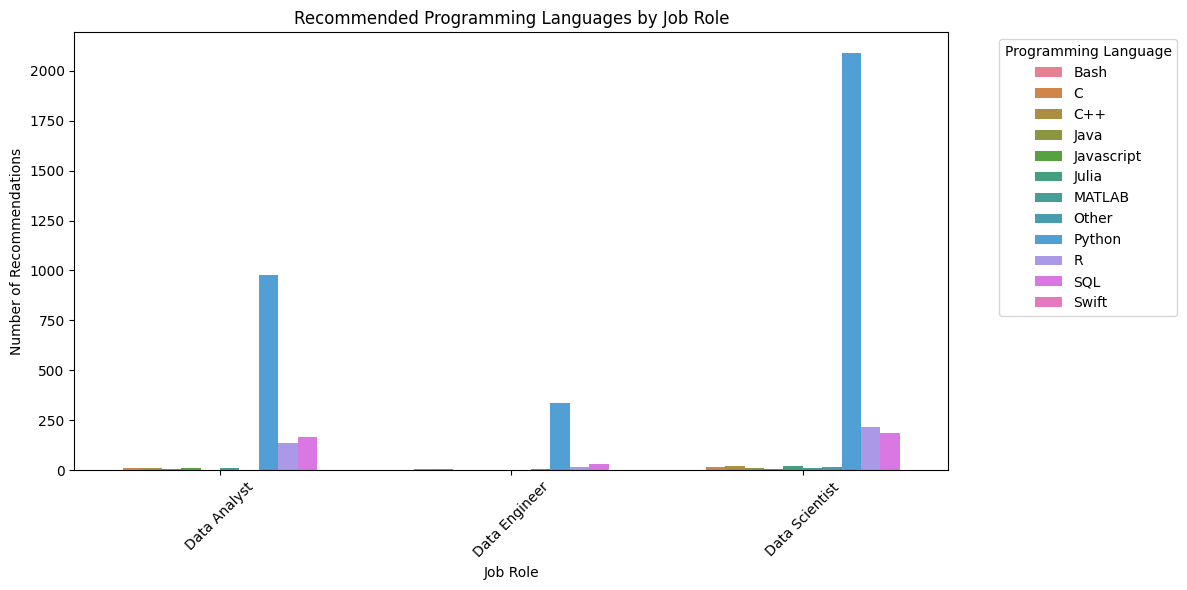

In [52]:
# My hypothesis:
# (Write your hypothesis here as a comment before coding)

# --- YOUR CODE HERE ---the Python is the most recommended programming language for Data Engineers, while R is more recommended for Data Scientists and Data Analysts.

import seaborn as sns
import matplotlib.pyplot as plt

# Select the three roles
three_roles = ["Data Scientist", "Data Analyst", "Data Engineer"]

df_roles = df[
    df["latest_job_role"].isin(three_roles)
].copy()

# Count programming language recommendations by role
language_counts = (
    df_roles
    .groupby(["latest_job_role", "programming_language_recommended"])
    .size()
    .reset_index(name="count")
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=language_counts,
    x="latest_job_role",
    y="count",
    hue="programming_language_recommended"
)

# Labels and title
plt.xlabel("Job Role")
plt.ylabel("Number of Recommendations")
plt.title("Recommended Programming Languages by Job Role")

plt.xticks(rotation=45)
plt.legend(title="Programming Language", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


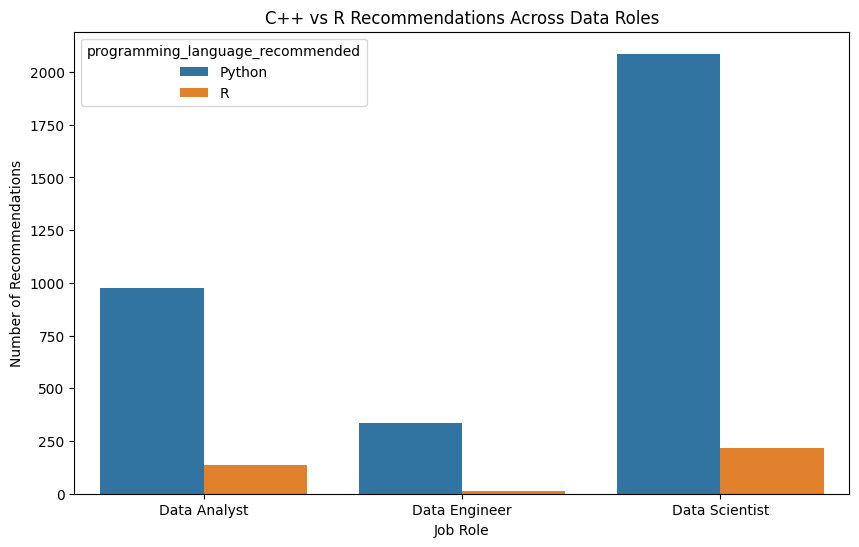

In [53]:
language_focus = language_counts[
    language_counts["programming_language_recommended"].isin(["Python", "R"])
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=language_focus,
    x="latest_job_role",
    y="count",
    hue="programming_language_recommended"
)

plt.xlabel("Job Role")
plt.ylabel("Number of Recommendations")
plt.title("C++ vs R Recommendations Across Data Roles")

plt.show()

**My conclusion**:

*(Write one sentence here explaining what your plot shows)*

---

## Final Checkpoint: Explanatory vs Exploratory

Look back at all your plots in this notebook.

1. Which of your plots is the most **explanatory** (polished, clear message, ready for a stakeholder)?
   What would you change to make it presentation-ready?

2. Which of your plots is the most **exploratory** (rough but revealed a discovery)?

3. For each plot, note which library you used. Did you naturally choose different libraries for different tasks? If so, what drove those choices?

4. If you had to deliver these findings to a non-technical manager in 5 minutes, which **three** plots would you show?

> **Great work!** You have now applied data visualization to a real-world survey dataset across three different Python libraries. Review [1_Exploratory_vs_explanatory_viz.md](1_Exploratory_vs_explanatory_viz) to revisit the principles behind when and how to communicate your findings and check out [5_Fantastic_charts](5_Fantastic_charts.ipynb).